Final Exam: Machine Learning - Regression and Classification from Scratch




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from numpy import random

In [ ]:
def transpose(M):
  n, m = M.shape
  Mt = np.zeros((m, n))
  for i in range(len(M)):
    for j in range(len(M[0])):
      Mt[j][i] = M[i][j]
  return Mt

def dot(M, v):
  res = np.zeros(len(M))
  for i in range(len(M)):
    for j in range(len(M[0])):
      res[i] += M[i][j] * v[j]
  return res

def hypothesis(theta, X):
    return dot(X, theta)

def BGD(X, y, alpha, theta, epochs): #batch gradient descent
  m = X.shape[0]
  cost = np.zeros(epochs)
  for epoch in range(epochs):
    h = hypothesis(theta, X)
    for j in range(len(theta)):
      gradient = np.sum((h - y) * X[:, j])
      theta[j] -= alpha / m * gradient
    cost[epoch] = 1 / (2 * m) * np.sum(np.square(h - y))
  return theta, cost

def get_poly_features(X, degree):
  m, n = X.shape
  X_poly = []
  for i in range(n):
    for d in range(1, degree + 1):
      X_poly.append(X[:,i] ** d)
  X_poly = np.column_stack(X_poly)
  return X_poly

def poly_regression(X, y, alpha, epochs, degree):
  m, n = X.shape

  bias = np.ones((m, 1))
  X_bias = np.concatenate((bias, X), axis=1) #adding the bias term
  X_poly = get_poly_features(X_bias, degree)

  theta = np.zeros(X_poly.shape[1])

  theta, cost = BGD(X_poly, y, alpha, theta, epochs)
  return theta, cost


# Linear Regression

In [ ]:
np.random.seed(42)
m = 200 #records
n = 3 #features
X = 3 * np.random.rand(m, n)
y = 12 + 2 * X[:, 0] + X[:, 1] ** 2 - 5 * (X[:, 2] ** 3)
y += np.random.rand(m) #adding noise
actual_theta = np.array([12, 2, 1, -5])

[ 20.43897279   4.48723723   6.3767032  -36.60986861]
[ 34.63531337   1.50803601   3.25517893 -38.95796729]


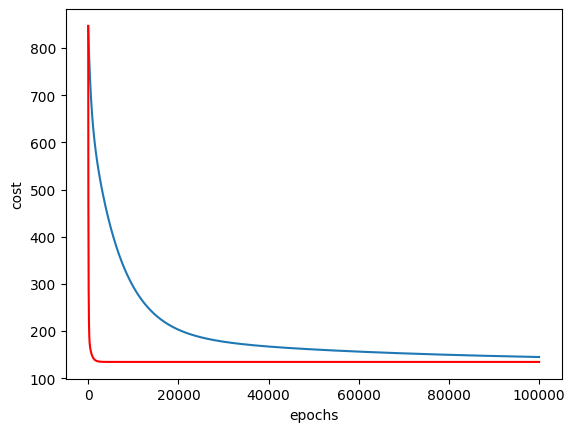

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)

theta, cost = poly_regression(X_train, y_train, 0.0001, 100000, 1)
cost = list(cost)
n_iterations = [x for x in range(1, 100001)]

theta_alpha2, cost_alpha2 = poly_regression(X_train, y_train, 0.01, 100000, 1)

plt.plot(n_iterations, cost)
plt.plot(n_iterations, cost_alpha2, c='r')
plt.xlabel('epochs')
plt.ylabel('cost')
print(theta)
print(theta_alpha2)

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)

print("Bias and coefficients:")
print("sklearn: ", reg.intercept_, reg.coef_)
print("alpha = 0.0001: ", theta)
print("alpha = 0.01: ", theta_alpha2)

Bias and coefficients:
sklearn:  34.635313372897656 [  1.50803601   3.25517893 -38.95796729]
alpha = 0.0001:  [ 20.43897279   4.48723723   6.3767032  -36.60986861]
alpha = 0.01:  [ 34.63531337   1.50803601   3.25517893 -38.95796729]


Text(0.5, 0, 'predicted')

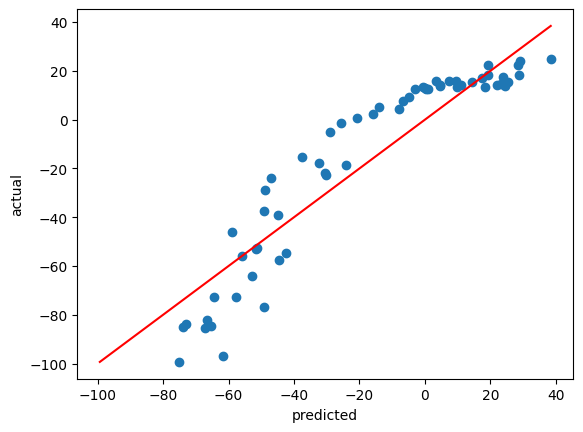

In [ ]:
y_pred = theta[0] + dot(X_test, theta[1:])
plt.scatter(y_pred, y_test)

min_val = min(y_pred.min(), y_test.min())
max_val = max(y_pred.max(), y_test.max())

plt.plot([min_val, max_val], [min_val, max_val], c='r') #the perfect prediction line

plt.ylabel('actual')
plt.xlabel('predicted')

Text(0.5, 0, 'predicted')

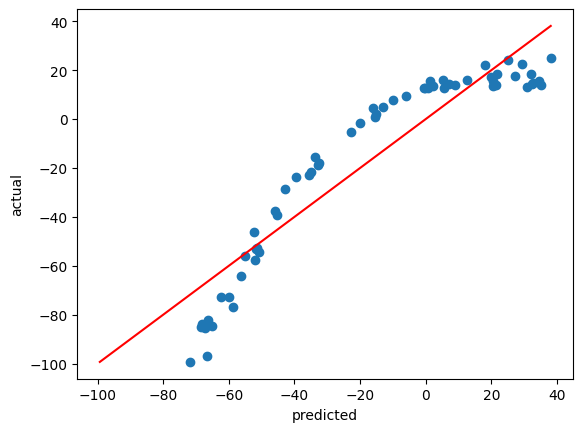

In [ ]:
y_pred_alpha2 = theta_alpha2[0] + dot(X_test, theta_alpha2[1:])
plt.scatter(y_pred_alpha2, y_test)

min_val = min(y_pred_alpha2.min(), y_test.min())
max_val = max(y_pred_alpha2.max(), y_test.max())

plt.plot([min_val, max_val], [min_val, max_val], c='r') #the perfect prediction line

plt.ylabel('actual')
plt.xlabel('predicted')

In [ ]:
y_train_pred = theta[0] + dot(X_train, theta[1:])
y_train_pred_alpha2 = theta_alpha2[0] + dot(X_train, theta_alpha2[1:])

train_mse = np.mean((y_train - y_train_pred)**2)
test_mse = np.mean((y_test - y_pred)**2)

train_mse_alpha2 = np.mean((y_train - y_train_pred_alpha2)**2)
test_mse_alpha2 = np.mean((y_test - y_pred_alpha2)**2)

print(f"Train MSE for alpha = 0.0001: {train_mse:.4f}")
print(f"Test  MSE for alpha = 0.0001: {test_mse:.4f}")

print(f"Train MSE for alpha = 0.01: {train_mse_alpha2:.4f}")
print(f"Test  MSE for alpha = 0.01: {test_mse_alpha2:.4f}")

Train MSE for alpha = 0.0001: 289.9774
Test  MSE for alpha = 0.0001: 194.1649
Train MSE for alpha = 0.01: 269.1519
Test  MSE for alpha = 0.01: 193.5301


In [ ]:
R2_test = 1 - np.sum((y_test - y_pred) ** 2)/np.sum((y_test - np.mean(y_test)) ** 2)
R2_train = 1 - np.sum((y_train- y_train_pred) ** 2)/np.sum((y_train - np.mean(y_train)) ** 2)
print(f"Train R^2: {R2_train:.4f}")
print(f"Test  R^2: {R2_test:.4f}")

Train R^2: 0.8087
Test  R^2: 0.8692


Train $R^2$ is slightly smaller than test $R^2$, which suggests high bias and underfitting

# Polynomial Regression

Text(0, 0.5, 'cost')

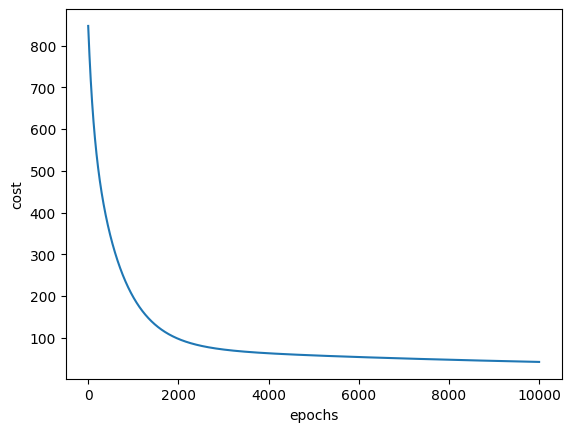

In [ ]:
degree = 2
theta, cost = poly_regression(X_train, y_train, 0.0001, 10000, degree)
cost = list(cost)
n_iterations = [x for x in range(1, 10001)]
plt.plot(n_iterations, cost)
plt.xlabel('epochs')
plt.ylabel('cost')

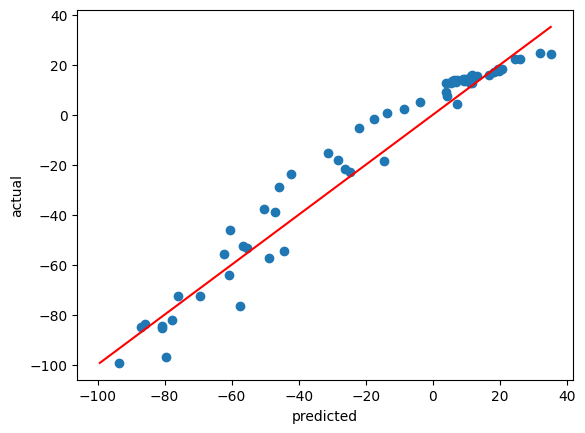

In [ ]:
m_test = X_test.shape[0]

bias = np.ones((m_test, 1))
X_bias_test = np.concatenate((bias, X_test), axis=1)

X_poly_test = get_poly_features(X_bias_test, degree)

y_pred = dot(X_poly_test, theta)

plt.scatter(y_pred, y_test)

min_val = min(y_pred.min(), y_test.min())
max_val = max(y_pred.max(), y_test.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r')

plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

# Binary Classification Algorithm

In [ ]:
def sigmoid_hypothesis(X, theta):
  z = dot(X, theta)
  h = 1 / (1 + np.exp(-z))
  return h

def BGD_classification(X, y, alpha, theta, epochs):
  m = X.shape[0]
  cost = np.zeros(epochs)
  for epoch in range(epochs):
    h = sigmoid_hypothesis(X, theta)
    gradient = (1/m) * dot(transpose(X), (h - y))
    theta -= alpha * gradient
    cost[epoch] = -(1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
  return theta, cost

def logistic_regression(X, y, alpha, epochs):
  m, n = X.shape
  theta = np.zeros(n + 1)
  bias = np.ones((m, 1))
  X_bias = np.concatenate((bias, X), axis=1)
  theta, cost = BGD_classification(X_bias, y, alpha, theta, epochs)
  return theta, cost

def predict_classification(X_test, theta):
  bias = np.ones((X_test.shape[0], 1))
  X_bias = np.concatenate((bias, X_test), axis=1)
  h = sigmoid_hypothesis(X_bias, theta)
  y_pred = np.zeros(len(h))
  print(h.shape, y_pred.shape)
  for i in range(len(h)):
    y_pred[i] = int(h[i] > 0.5)
  return y_pred

In [ ]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X=cancer.data
y=cancer.target
X = (X - X.min()) / (X.max() - X.min()) #normalization
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)

Text(0, 0.5, 'cost')

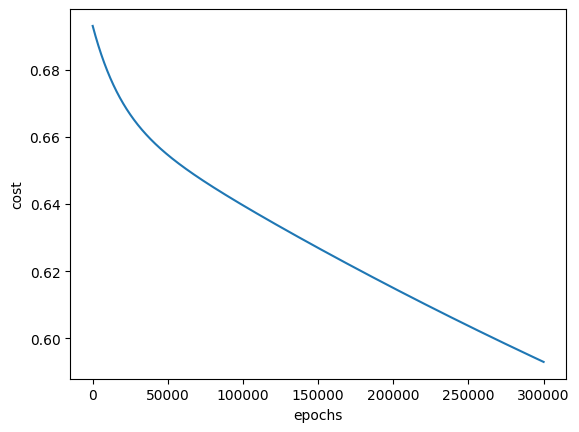

In [ ]:
theta, cost = logistic_regression(X_train, y_train, 0.0001, 300000)
cost = list(cost)
n_iterations = [x for x in range(1, 300001)]
plt.plot(n_iterations, cost)
plt.xlabel('epochs')
plt.ylabel('cost')

Text(0, 0.5, 'cost')

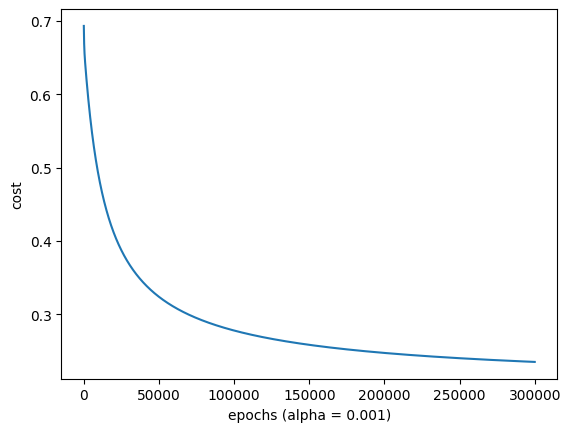

In [ ]:
theta, cost = logistic_regression(X_train, y_train, 0.01, 300000)
cost = list(cost)
n_iterations = [x for x in range(1, 300001)]
plt.plot(n_iterations, cost)
plt.xlabel('epochs (alpha = 0.01)')
plt.ylabel('cost')

(171,) (171,)


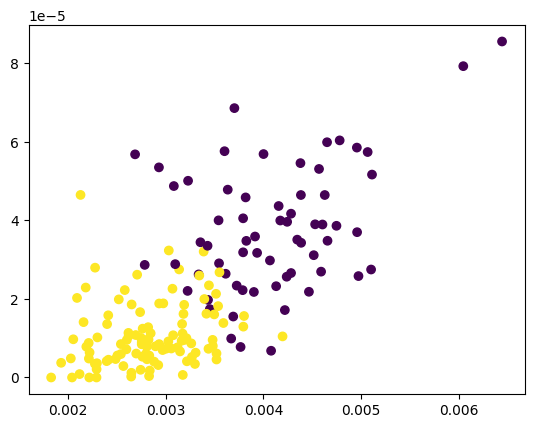

In [ ]:
y_pred = predict_classification(X_test, theta)
plt.scatter(X_test[:,0], X_test[:,6], c=y_test)

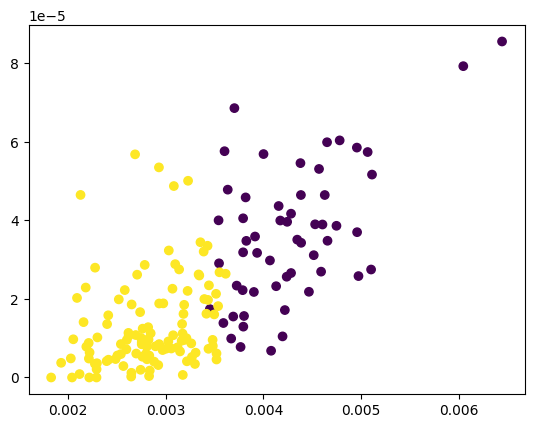

In [ ]:
plt.scatter(X_test[:,0], X_test[:,6], c=y_pred)